# Load in data

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import xarray as xr
import numpy as np
import matplotlib.patches as mpatches
import pandas as pd
import time
import matplotlib.animation as animation
import alphashape
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

temp_groups = ['205', '218', '225']
color_map = {
    '205': 'gray',
    '218': 'red',
    '225': 'green'
}

rho_ice = 917.0  # kg/m^3, used for CoCiP mass calculation
model_colors = {"APCEMM": "tab:blue", "LES": "tab:orange", "CoCiP": "tab:green"}
rh_styles = {110: "--", 130: "-"}

In [2]:
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours = [0, 12]
habits = ['ghm', 'solid-column', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

# CoCiP
C1 = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/constIWC_const_r/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
C2 = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
C3 = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/calcIWC_const_r/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
C4 = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/gaussIWC_calc_r/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
C5 = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/gaussIWC_gauss_r/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# APCEMM
apcemm_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/ef_final/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

apcemm_default_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/default_settings/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# LES
les_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/LES/ef_final/{tid}/LES_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

model_names = ['C1', 'C2', 'C3', 'C4', 'C5', 'APCEMM', 'APCEMM_d', 'LES']
TARGET_AGE_H = 4.0

In [3]:
print(apcemm_data[('110T218L25', 0, 'ghm')]['IWC AI'][5].values) 
print(f"{np.nanmean(apcemm_data[('110T218L25', 0, 'ghm')]['IWC slices'][5].values)}\n")
print(apcemm_data[('110T218L25', 0, 'ghm')]['Depth AI'][5].values) 
print(f"{np.nanmean(apcemm_data[('110T218L25', 0, 'ghm')]['Depth slices'][5].values)}\n")
print(apcemm_data[('110T218L25', 0, 'ghm')]['Effective radius AI'][5].values)
print(f"{np.nanmean(apcemm_data[('110T218L25', 0, 'ghm')]['Effective radius slices'][5].values)}\n")

0.0002445849
0.0013281589650432583

294.0
167.27667277018227

6.839796
12.343938280741375



In [4]:
print(apcemm_data[("110T218L25", 0, 'ghm')]["Energy Forcing AI"][-1].values / apcemm_data[("110T218L25", 0, 'ghm')]["Energy Forcing"][-1].values)

0.8383242234395731


# Plot EF for different CoCiP slicing methods

In [ ]:
# ── data paths & keys ────────────────────────────────────────────────────────
test_ids = ['110T218L25', '130T218L25']
hours    = [0, 12]
habits = ['ghm', 'solid-column', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

TARGET_AGE_H = 4.0

# ── accumulate per-habit EF values ───────────────────────────────────────────
# Keyed by (tid, model, hour, habit) — one scalar each
model_names_to_plot = ['C1', 'C2', 'C3', 'C4', 'C5']
per_case    = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in model_names_to_plot} for tid in test_ids}
per_case_4h = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in model_names_to_plot} for tid in test_ids}

for m in model_names_to_plot:
    for tid in test_ids:
        for hour in hours:
            for habit in habits:
                ds = get_ds(m, tid, hour, habit)
                if ds is None:
                    continue

                age     = get_age_coord(ds, m)
                ef_vals = ds['Energy Forcing'].values.astype(float)

                # full run: last EF value (remove index-0 for APCEMM)
                ef_full = ef_vals
                if len(ef_full) > 0:
                    per_case[tid][m][hour][habit] = float(ef_full[-1])

                # 4h truncated: last EF value at or before 4 h
                ef_4h = ef_vals[age <= TARGET_AGE_H]
                if len(ef_4h) > 0:
                    per_case_4h[tid][m][hour][habit] = float(ef_4h[-1])

# ── CoCiP internal EF (unchanged logic) ──────────────────────────────────────

cocip_internal = {}
for m in model_names_to_plot:
    for tid in test_ids:
        for hour in hours:
            cocip_internal[(tid, hour, 'none')] = get_cocip_internal_point(tid, hour, None, m)
            cocip_internal[(tid, hour, '4h')]   = get_cocip_internal_point(tid, hour, TARGET_AGE_H, m)

# ── layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=300, sharey=False)

temps_unique = sorted({int(tid.split('T')[1].split('L')[0]) for tid in test_ids})

groups = []
for T in temps_unique:
    for tid in sorted([t for t in test_ids if f"T{T}" in t],
                      key=lambda s: int(s[:3])):
        groups.append((T, tid))

model_order  = model_names_to_plot
n_models     = len(model_order)
n_habits     = len(habits)
sub_bar_w    = 0.07   # width of each individual habit bar
model_gap    = 0.04   # gap between model clusters
group_gap    = 0.14   # extra gap between temperature groups

model_cluster_w = n_habits * sub_bar_w  # total width of one model's 3 bars

group_starts = group_x_positions(groups)

x_left  = -0.2
x_right = group_starts[-1] + n_models * (model_cluster_w + model_gap) + 0.1

# ── CoCiP internal scatter ────────────────────────────────────────────────────
# Place the scatter at the horizontal center of the CoCiP model cluster
cocip_idx = model_order.index('C2')

# ── main panels ───────────────────────────────────────────────────────────────
panel_info = list(zip(axes, hours, ['Midnight', 'Noon']))

for ax, hour, title in panel_info:
    draw_bars(ax, hour)
    draw_cocip_internal(ax, hour)

    ax.axhline(0, color='gray', linestyle='--', lw=0.8)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xticks([])
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xlim(x_left, x_right)

# ── y limits ──────────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:
    ymins, ymaxs = [], []
    for tid in test_ids:
        for m in model_order:
            for habit in habits:
                for val_dict in [per_case, per_case_4h]:
                    v = val_dict[tid][m][hour][habit]
                    if v is not None:
                        ymins.append(v)
                        ymaxs.append(v)
        for mode in ['none', '4h']:
            y_int = cocip_internal.get((tid, hour, mode), np.nan)
            if np.isfinite(y_int):
                ymins.append(y_int)
                ymaxs.append(y_int)

    ymin = min(ymins) if ymins else -1
    ymax = max(ymaxs) if ymaxs else  1
    pad  = 0.06 * (ymax - ymin)

    if hour == 0:
        ax.set_ylim(1e5, ymax + pad)
    else:
        ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_yscale('linear')

axes[0].set_ylabel('EF [J m$^{-1}$]', fontsize=16)

# ── x-tick labels ─────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:

    # RHI labels — centred on the full group of 3 model clusters
    for gi, (T, tid) in enumerate(groups):
        total_w = n_models * (model_cluster_w + model_gap) - model_gap
        xc = group_starts[gi] + total_w / 2
        rhi_str = tid[:3] + '%'
        ax.text(xc, -0.045, rhi_str, ha='center', va='top', fontsize=14,
                transform=ax.get_xaxis_transform(), clip_on=False)

    # Temperature labels
    prev_T, block_start_x = None, None

    for gi, (T, tid) in enumerate(groups):
        if T != prev_T:
            if prev_T is not None:
                flush_temp_label(ax, prev_T, block_start_x,
                                 group_starts[gi - 1] + n_models * (model_cluster_w + model_gap) - model_gap)
            block_start_x = group_starts[gi]
            prev_T = T

    flush_temp_label(ax, prev_T, block_start_x,
                     group_starts[-1] + n_models * (model_cluster_w + model_gap) - model_gap)

# ── legend ────────────────────────────────────────────────────────────────────
# Model patches (mid shade)
model_handles = [
    mpatches.Patch(facecolor=model_habit_colors[m]['solid-column'],
                   edgecolor=model_edge_colors[m], linewidth=0.8, label=m)
    for m in model_order
]

# Habit shade patches (using C1 palette as neutral reference)
habit_labels = {'ghm': 'GHM', 'solid-column': 'Solid Column', 'rough-aggregate': 'Rough Aggregate'}
habit_handles = [
    mpatches.Patch(facecolor=model_habit_colors['C1'][hab],
                   edgecolor=model_edge_colors['C1'], linewidth=0.8,
                   label=habit_labels[hab])
    for hab in habits
]

full_patch = mpatches.Patch(facecolor='lightgray', edgecolor='gray',
                             linewidth=0.8, label='Full Lifetime')
trunc_patch = mpatches.Patch(facecolor='None', edgecolor='gray',
                              hatch='///', label='Synoptic Lifetime')

internal_none_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                   color='black', markerfacecolor='black',
                                   markeredgecolor='black', markersize=6,
                                   label='CoCiP Internal')
internal_4h_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                 color='black', markerfacecolor='none',
                                 markeredgecolor='black', markersize=6,
                                 label='CoCiP Internal - Synoptic')

fig.legend(
    handles=model_handles + [full_patch, trunc_patch,
                                              internal_none_handle, internal_4h_handle],
    loc='lower center',
    ncol=7,
    fontsize=14,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02)
)

# ── final layout ──────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

In [ ]:
C1_IWC_slices = C1[('110T218L25', 0, 'ghm')]['IWC slices'][6].values
C2_IWC_slices = C2[('110T218L25', 0, 'ghm')]['IWC slices'][6].values
C3_IWC_slices = C3[('110T218L25', 0, 'ghm')]['IWC slices'][6].values
C4_IWC_slices = C4[('110T218L25', 0, 'ghm')]['IWC slices'][6].values
C5_IWC_slices = C5[('110T218L25', 0, 'ghm')]['IWC slices'][6].values

C1_radius_slices = C1[('110T218L25', 0, 'ghm')]['Effective radius slices'][6].values
C2_radius_slices = C2[('110T218L25', 0, 'ghm')]['Effective radius slices'][6].values
C3_radius_slices = C3[('110T218L25', 0, 'ghm')]['Effective radius slices'][6].values
C4_radius_slices = C4[('110T218L25', 0, 'ghm')]['Effective radius slices'][6].values
C5_radius_slices = C5[('110T218L25', 0, 'ghm')]['Effective radius slices'][6].values

for m in model_names:
    if m == 'C1':
        fig, ax = plt.subplots(figsize=(4,3), dpi=200)
        ax_r = ax.twinx()
        ax.plot(C1_IWC_slices, color=model_edge_colors['C1'], label='C1 - Constant IWC')
        ax_r.plot(C1_radius_slices, color=model_edge_colors['C1'], linestyle='--')
    elif m == 'C2':
        fig, ax = plt.subplots(figsize=(4,3), dpi=200)
        ax_r = ax.twinx()
        ax.plot(C2_IWC_slices, color=model_edge_colors['C2'], label='C2 - Gaussian IWC')
        ax_r.plot(C2_radius_slices, color=model_edge_colors['C2'], linestyle='--')
    elif m == 'C3':
        fig, ax = plt.subplots(figsize=(4,3), dpi=200)
        ax_r = ax.twinx()
        ax.plot(C3_IWC_slices, color=model_edge_colors['C3'], label='C3 - Calc IWC')
        ax_r.plot(C3_radius_slices, color=model_edge_colors['C3'], linestyle='--')
    elif m == 'C4':
        fig, ax = plt.subplots(figsize=(4,3), dpi=200)
        ax_r = ax.twinx()
        ax.plot(C4_IWC_slices, color=model_edge_colors['C4'], label='C4 - ')
        ax_r.plot(C4_radius_slices, color=model_edge_colors['C4'], linestyle='--')
    elif m == 'C5':
        fig, ax = plt.subplots(figsize=(4,3), dpi=200)
        ax_r = ax.twinx()
        ax.plot(C5_IWC_slices, color=model_edge_colors['C5'], label='C5 - ')
        ax_r.plot(C5_radius_slices, color=model_edge_colors['C5'], linestyle='--')

    ax.set_xlabel('Slice Index', fontsize=14)
    ax.set_ylabel('IWC [g/m^3]', fontsize=14)
    ax_r.set_ylabel('Effective Radius [μm]', fontsize=14)

# ax.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
idx_list = [1, 6, 24]  # 10 min, 1h, 4h, 8h
fig, axes = plt.subplots(4, len(idx_list), figsize=(18, 10), dpi=300, sharex='col', sharey='row')

test_id = '110T218L25'
tod = 0  # 0 for midnight, 12 for noon
width = 1

C_colors = ['red', 'blue', 'green', 'orange', 'pink']

def plot_lines(ax, slice_indices, data_dict, colors_dict, marker='o', linewidth=1.5):
    """
    data_dict: {'C1': array, 'C2': array, ...} — values per slice index
    colors_dict: {'C1': color, ...}
    """
    for label, vals in data_dict.items():
        ax.plot(slice_indices, vals, color=colors_dict[label],
                marker=marker, markersize=4, linewidth=linewidth,
                label=label, alpha=0.9)

    ax.legend(fontsize=9)

for col, idx in enumerate(idx_list):
    time = idx * 10 / 60  # hours

    C1_plot_data = C1[(test_id, tod, 'ghm')].sel(t=idx, method="nearest")
    C2_plot_data = C2[(test_id, tod, 'ghm')].sel(t=idx, method="nearest")
    C3_plot_data = C3[(test_id, tod, 'ghm')].sel(t=idx, method="nearest")
    C4_plot_data = C4[(test_id, tod, 'ghm')].sel(t=idx, method="nearest")
    C5_plot_data = C5[(test_id, tod, 'ghm')].sel(t=idx, method="nearest")

    slice_indices = np.arange(len(C1_plot_data['Effective radius slices']))

    C1_data_radii = C1_plot_data['Effective radius slices']
    C1_data_depth = C1_plot_data['Depth slices']
    C1_data_iwc =   C1_plot_data['IWC slices']
    C1_data_LW =    C1_plot_data['LW RF slices midnight']

    C2_data_radii = C2_plot_data['Effective radius slices']
    C2_data_depth = C2_plot_data['Depth slices']
    C2_data_iwc =   C2_plot_data['IWC slices']
    C2_data_LW =    C2_plot_data['LW RF slices midnight']

    C3_data_radii = C3_plot_data['Effective radius slices']
    C3_data_depth = C3_plot_data['Depth slices']
    C3_data_iwc =   C3_plot_data['IWC slices']
    C3_data_LW =    C3_plot_data['LW RF slices midnight']

    C4_data_radii = C4_plot_data['Effective radius slices']
    C4_data_depth = C4_plot_data['Depth slices']
    C4_data_iwc =   C4_plot_data['IWC slices']
    C4_data_LW =    C4_plot_data['LW RF slices midnight']

    C5_data_radii = C5_plot_data['Effective radius slices']
    C5_data_depth = C5_plot_data['Depth slices']
    C5_data_iwc =   C5_plot_data['IWC slices']
    C5_data_LW =    C5_plot_data['LW RF slices midnight']


    ax = axes[0, col]
    plot_lines(
        ax, slice_indices,
        data_dict={'C1': C1_data_depth, 'C2': C2_data_depth, 'C3': C3_data_depth,
                   'C4': C4_data_depth, 'C5': C5_data_depth},
        colors_dict={'C1': C_colors[0], 'C2': C_colors[1], 'C3': C_colors[2],
                     'C4': C_colors[3], 'C5': C_colors[4]},
    )
    ax.set_ylabel('Depth [m]', fontsize=12)
    ax.set_title(f"idx={idx}, age={time:.1f} h")

    ax = axes[1, col]
    plot_lines(
        ax, slice_indices,
        data_dict={'C1': C1_data_radii, 'C2': C2_data_radii, 'C3': C3_data_radii,
                   'C4': C4_data_radii, 'C5': C5_data_radii},
        colors_dict={'C1': C_colors[0], 'C2': C_colors[1], 'C3': C_colors[2],
                     'C4': C_colors[3], 'C5': C_colors[4]},
    )
    ax.set_ylabel('Effective Radius [µm]', fontsize=12)

    ax = axes[2, col]
    plot_lines(
        ax, slice_indices,
        data_dict={'C1': C1_data_iwc, 'C2': C2_data_iwc, 'C3': C3_data_iwc,
                   'C4': C4_data_iwc, 'C5': C5_data_iwc},
        colors_dict={'C1': C_colors[0], 'C2': C_colors[1], 'C3': C_colors[2],
                     'C4': C_colors[3], 'C5': C_colors[4]},
    )
    ax.set_ylabel('IWC [g/m³]', fontsize=12)

    ax = axes[3, col]
    plot_lines(
        ax, slice_indices,
        data_dict={'C1': C1_data_LW, 'C2': C2_data_LW, 'C3': C3_data_LW,
                   'C4': C4_data_LW, 'C5': C5_data_LW},
        colors_dict={'C1': C_colors[0], 'C2': C_colors[1], 'C3': C_colors[2],
                     'C4': C_colors[3], 'C5': C_colors[4]},
    )
    ax.set_ylabel('LW RF [W/m²]', fontsize=12)
    ax.set_xlabel('Slice Index', fontsize=12)
    

for row in range(4):
    for col in range(len(idx_list)):
        axes[row, col].set_xlim(-1, len(slice_indices))
        if row == 3:
            axes[row, col].set_xlabel('Slice Index', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
all_datasets = [C1, C2, C3, C4, C5]
j = 0  # Counter to track the first iteration for header writing
tod = 0
for tid in test_ids:
    for ds in all_datasets:
        print(f"Processing dataset for test_id={tid}, tod={tod}")
        model_data = ds[(test_id, tod, 'ghm')]  # Example habit; adjust as needed

        try:
            age_hours = model_data['age_hours'].values.astype(float)
        except:
            try:
                age_hours = model_data.t.values
            except:
                try:
                    age_hours = model_data.time.values
                except:
                    print(f"Not an APCEMM, CoCiP, or LES dataset")
                    continue

        for idx, time in enumerate(age_hours):
            print(f"Processing idx={idx}, age={time:.2f} h")

            try:
                plot_data = model_data.sel(t=idx, method="nearest")
            except:
                try:
                    plot_data = model_data.sel(time=idx, method="nearest")
                except:
                    print(f"Not an APCEMM, CoCiP, or LES dataset")
                    continue

            data_LW = plot_data['LW RF slices midnight']

            if np.isnan(data_LW).any():
                print(f"Skipping idx={idx} due to NaN values in LW RF slices")
                continue

            data_radii = plot_data['Effective radius slices']
            data_depth = plot_data['Depth slices']
            data_iwc = plot_data['IWC slices']

            # data_LW = np.array(np.where(data_radii < 5.8, np.nan, data_LW))
            # data_radii = np.array(np.where(data_radii < 5.8, np.nan, data_radii))
            # data_depth = np.array(np.where(data_radii < 5.8, np.nan, data_depth))
            # data_iwc = np.array(np.where(data_radii < 5.8, np.nan, data_iwc))


            # Stack cocip data into columns for CSV output
            data = np.column_stack([
                data_radii,
                data_depth,
                data_iwc,
                data_LW
            ])

            # Append to CSV (write header only on first iteration)
            if j == 0:
                np.savetxt("cocip_slice_data_all_LW.csv", data, delimiter=",", fmt="%e", 
                           header="Effective Radius [µm], Depth [m], IWC [g/m³], LW RF [W/m²]", comments="")
            else:
                with open("cocip_slice_data_all_LW.csv", "ab") as f:
                    np.savetxt(f, data, delimiter=",", fmt="%e")
            j += 1

## Log regression

In [ ]:
# %% [markdown]
# # Fitting the Relationship Between CoCiP Contrail Variables
#
# **Goal:** Find a simple, interpretable equation that relates three independent
# inputs — Effective Radius, Depth, and Ice Water Content (IWC) — to the output
# variable, Longwave Radiative Forcing (LW RF).
#
# **Approach:**
# 1. Load and inspect the data.
# 2. Check whether the inputs are actually statistically independent (an
#    assumption worth verifying, not just assuming).
# 3. Fit a plain **linear** model: `Y = C + a*X1 + b*X2 + c*X3`
# 4. Fit a **power-law** model: `Y = C * X1^a * X2^b * X3^c`, by taking logs
#    of everything and running linear regression in log-space. This is the
#    natural model when you care about statements like "doubling A doubles Y" —
#    the exponent directly tells you the answer.
# 5. Compare fit quality (R^2) and pick the better-supported model.
# 6. Visualize actual vs. predicted values and residuals to sanity-check the fit.
#
# Each step below is heavily commented so you can adapt this to new datasets.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# %% [markdown]
# ## 1. Load the data
#
# Update `DATA_PATH` to point at your CSV. We also strip whitespace from
# column names and rename them to short, code-friendly labels so the rest of
# the script stays readable.

# %%
DATA_PATH = "cocip_slice_data_all_LW.csv"  # <-- update path as needed

df = pd.read_csv(DATA_PATH)
df = df.dropna()  # Drop any rows with missing values, if present
df.columns = [c.strip() for c in df.columns]

# Rename to short handles for convenience.
# Original columns: 'Effective Radius [µm]', 'Depth [m]', 'IWC [g/m³]', 'LW RF [W/m²]'
df.columns = ["ER", "Depth", "IWC", "LWRF"]

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

# %%
# Quick sanity checks before modeling:
#  - Are there missing values?
#  - Are there zero/negative values? (These break log-space fitting, since
#    log(0) and log(negative) are undefined.)
print("Missing values per column:")
print(df.isna().sum())

print("\nNon-positive values per column (would break log-log fit):")
print((df <= 0).sum())

print("\nSummary statistics:")
df.describe()

# %% [markdown]
# ## 2. Check the "independent inputs" assumption
#
# The analysis goal assumes the three inputs are independent of one another.
# That's often true *by design* in a controlled experiment, but it's worth
# verifying empirically, especially with simulation output (like CoCiP model
# slices) where variables may co-evolve along a trajectory rather than being
# independently sampled.
#
# We compute the pairwise Pearson correlation matrix. Values close to 0
# support independence; values with |r| > ~0.3-0.4 suggest the inputs move
# together in this dataset, which means fitted coefficients should be
# interpreted a bit more cautiously (they describe the fitted relationship
# *in this data*, not necessarily what you'd see if each input were varied
# in true isolation).

# %%
corr_matrix = df[["ER", "Depth", "IWC"]].corr()
print("Correlation matrix of inputs:")
print(corr_matrix.round(3))

# %% [markdown]
# ## 3. Fit a linear model
#
# `LWRF = C + a*ER + b*Depth + c*IWC`
#
# This is the simplest possible relationship: each unit increase in an input
# adds a fixed amount to the output, regardless of the current value of that
# input. It's a good baseline, but real physical systems often aren't linear
# across their full range (e.g., diminishing or accelerating returns).

# %%
X = df[["ER", "Depth", "IWC"]].values
y = df["LWRF"].values

linear_model = LinearRegression().fit(X, y)
y_pred_linear = linear_model.predict(X)
r2_linear = r2_score(y, y_pred_linear)

print("=== LINEAR MODEL: LWRF = C + a*ER + b*Depth + c*IWC ===")
print(f"Intercept (C):     {linear_model.intercept_:.4f}")
print(f"Coefficient (ER):    {linear_model.coef_[0]:.5f}")
print(f"Coefficient (Depth): {linear_model.coef_[1]:.5f}")
print(f"Coefficient (IWC):   {linear_model.coef_[2]:.5f}")
print(f"R^2 = {r2_linear:.5f}")

# %% [markdown]
# ## 4. Fit a power-law model (log-log regression)
#
# `LWRF = C * ER^a * Depth^b * IWC^c`
#
# Taking the natural log of both sides turns this into an ordinary linear
# regression on the logged variables:
#
# `log(LWRF) = log(C) + a*log(ER) + b*log(Depth) + c*log(IWC)`
#
# This form is especially useful for "doubling" questions: if `a` is the
# fitted exponent for ER, then doubling ER multiplies LWRF by `2^a`, holding
# the other inputs fixed. That's a much more direct answer to "how does
# doubling A affect Y?" than a linear coefficient gives you.
#
# We already confirmed above that all values are strictly positive, so
# log-transforming is safe here.

# %%
log_X = np.log(X)
log_y = np.log(y)

loglog_model = LinearRegression().fit(log_X, log_y)
log_y_pred = loglog_model.predict(log_X)
r2_loglog_logspace = r2_score(log_y, log_y_pred)

# Recover the multiplicative constant C from the intercept (which is log(C))
C = np.exp(loglog_model.intercept_)
a, b, c = loglog_model.coef_

print("=== POWER-LAW MODEL: LWRF = C * ER^a * Depth^b * IWC^c ===")
print(f"C = {C:.5f}")
print(f"Exponent a (ER):    {a:.4f}")
print(f"Exponent b (Depth): {b:.4f}")
print(f"Exponent c (IWC):   {c:.4f}")
print(f"R^2 (log space)     = {r2_loglog_logspace:.5f}")

# Also compute R^2 back in the ORIGINAL units, so it's directly comparable
# to the linear model's R^2 above. (R^2 in log-space and in original units
# will generally differ because R^2 depends on the scale you measure error in.)
y_pred_loglog_original = np.exp(log_y_pred)
r2_loglog_original = r2_score(y, y_pred_loglog_original)
print(f"R^2 (original units) = {r2_loglog_original:.5f}")

# %% [markdown]
# ### Interpreting the exponents
#
# For each exponent `e`, doubling that input multiplies the output by `2^e`:
#  - `e = 1`   -> exactly proportional (doubling input doubles output)
#  - `e = 0.5` -> diminishing returns (doubling input increases output ~41%)
#  - `e = 0`   -> input has no effect
#  - `e < 0`   -> input and output move in opposite directions
#
# The cell below prints this out automatically for each fitted exponent.

# %%
for name, exponent in zip(["ER", "Depth", "IWC"], [a, b, c]):
    multiplier = 2 ** exponent
    pct_change = (multiplier - 1) * 100
    direction = "increases" if pct_change > 0 else "decreases"
    print(
        f"Doubling {name:5s} (exponent = {exponent:+.3f}) "
        f"{direction} LWRF by about {abs(pct_change):.1f}%"
    )

# %% [markdown]
# ## 5. Compare the two models
#
# We compare R^2 in the *original* units so the comparison is apples-to-apples.
# Higher R^2 means the model explains more of the variance in the data.

# %%
comparison = pd.DataFrame(
    {
        "Model": ["Linear", "Power-law (log-log)"],
        "R^2 (original units)": [r2_linear, r2_loglog_original],
    }
)
print(comparison.to_string(index=False))

best_model = "Power-law" if r2_loglog_original > r2_linear else "Linear"
print(f"\n--> Better-fitting model: {best_model}")

# %% [markdown]
# ## 6. Diagnostic plots
#
# Two standard regression diagnostics for the better-fitting model:
#  - **Actual vs. Predicted**: points should cluster tightly around the
#    diagonal (y = x) line if the model fits well.
#  - **Residuals vs. Predicted**: residuals should look like random scatter
#    around zero, with no obvious pattern (a pattern suggests the model is
#    missing some structure in the data).
#
# We plot the power-law model's fit here since it performed better; swap in
# `y_pred_linear` if you want to inspect the linear model instead.

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# --- Actual vs Predicted ---
axes[0].scatter(y, y_pred_loglog_original, alpha=0.5, s=15)
lims = [min(y.min(), y_pred_loglog_original.min()), max(y.max(), y_pred_loglog_original.max())]
axes[0].plot(lims, lims, "r--", label="Perfect fit (y = x)")
axes[0].set_xlabel("Actual LW RF [W/m²]")
axes[0].set_ylabel("Predicted LW RF [W/m²]")
axes[0].set_title("Power-Law Model: Actual vs. Predicted")
axes[0].legend()

# --- Residuals vs Predicted ---
residuals = y - y_pred_loglog_original
axes[1].scatter(y_pred_loglog_original, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted LW RF [W/m²]")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Power-Law Model: Residuals")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Final fitted equation
#
# Prints the final human-readable equation using the fitted constant and
# exponents from Step 4.

# %%
print("Final fitted relationship:\n")
print(f"LW RF  ≈  {C:.3f} × ER^({a:.3f}) × Depth^({b:.3f}) × IWC^({c:.3f})")

## Inverse hyperbolic sine for negative values

In [ ]:
# %% [markdown]
# # Fitting the Relationship Between CoCiP Contrail Variables
#
# **Goal:** Find a simple, interpretable equation that relates three independent
# inputs — Effective Radius, Depth, and Ice Water Content (IWC) — to the output
# variable, Shortwave Radiative Forcing (SW RF).
#
# **Approach:**
# 1. Load and inspect the data.
# 2. Check whether the inputs are actually statistically independent (an
#    assumption worth verifying, not just assuming).
# 3. Fit a plain **linear** model: `Y = C + a*X1 + b*X2 + c*X3`
# 4. Fit a **power-law** model: `Y = C * X1^a * X2^b * X3^c`, by taking logs
#    of everything and running linear regression in log-space. This is the
#    natural model when you care about statements like "doubling A doubles Y" —
#    the exponent directly tells you the answer.
# 5. Compare fit quality (R^2) and pick the better-supported model.
# 6. Visualize actual vs. predicted values and residuals to sanity-check the fit.
#
# Each step below is heavily commented so you can adapt this to new datasets.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# %% [markdown]
# ## 1. Load the data
#
# Update `DATA_PATH` to point at your CSV. We also strip whitespace from
# column names and rename them to short, code-friendly labels so the rest of
# the script stays readable.

# %%
DATA_PATH = "cocip_slice_data_all_SW.csv"  # <-- update path as needed

df = pd.read_csv(DATA_PATH)
df = df.dropna()  # Drop any rows with missing values, if present
df.columns = [c.strip() for c in df.columns]

# Rename to short handles for convenience.
# Original columns: 'Effective Radius [µm]', 'Depth [m]', 'IWC [g/m³]', 'SW RF [W/m²]'
df.columns = ["ER", "Depth", "IWC", "SWRF"]

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

# %%
# Quick sanity checks before modeling:
#  - Are there missing values?
#  - Are there zero/negative values? (These break log-space fitting, since
#    log(0) and log(negative) are undefined.)
print("Missing values per column:")
print(df.isna().sum())

print("\nNon-positive values per column (would break log-log fit):")
print((df <= 0).sum())

print("\nSummary statistics:")
df.describe()

# %% [markdown]
# ## 2. Check the "independent inputs" assumption
#
# The analysis goal assumes the three inputs are independent of one another.
# That's often true *by design* in a controlled experiment, but it's worth
# verifying empirically, especially with simulation output (like CoCiP model
# slices) where variables may co-evolve along a trajectory rather than being
# independently sampled.
#
# We compute the pairwise Pearson correlation matrix. Values close to 0
# support independence; values with |r| > ~0.3-0.4 suggest the inputs move
# together in this dataset, which means fitted coefficients should be
# interpreted a bit more cautiously (they describe the fitted relationship
# *in this data*, not necessarily what you'd see if each input were varied
# in true isolation).

# %%
corr_matrix = df[["ER", "Depth", "IWC"]].corr()
print("Correlation matrix of inputs:")
print(corr_matrix.round(3))

def ihs(x):
    """Inverse hyperbolic sine: like log, but defined for negative x and zero."""
    return np.arcsinh(x)

log_X = np.log(X)          # ER, Depth, IWC — all positive, log as usual
ihs_y = ihs(y)              # SWRF — can be negative, use asinh

mixed_model = LinearRegression().fit(log_X, ihs_y)
ihs_y_pred = mixed_model.predict(log_X)
r2_mixed_transformed = r2_score(ihs_y, ihs_y_pred)

C_mixed = mixed_model.intercept_     # NOTE: additive in asinh-space, not a
                                       # simple multiplicative constant anymore
a, b, c = mixed_model.coef_

print("=== MIXED MODEL: asinh(SWRF) = C + a*log(ER) + b*log(Depth) + c*log(IWC) ===")
print(f"Intercept (C):      {C_mixed:.5f}")
print(f"Exponent a (ER):       {a:.4f}")
print(f"Exponent b (Depth):    {b:.4f}")
print(f"Exponent c (IWC):      {c:.4f}")
print(f"R^2 (asinh space)    = {r2_mixed_transformed:.5f}")

# Back-transform to original SWRF units for fair comparison to the linear model
y_pred_mixed_original = np.sinh(ihs_y_pred)
r2_mixed_original = r2_score(y, y_pred_mixed_original)
print(f"R^2 (original units) = {r2_mixed_original:.5f}")

# %% [markdown]
# ### Interpreting the exponents
#
# For each exponent `e`, doubling that input multiplies the output by `2^e`:
#  - `e = 1`   -> exactly proportional (doubling input doubles output)
#  - `e = 0.5` -> diminishing returns (doubling input increases output ~41%)
#  - `e = 0`   -> input has no effect
#  - `e < 0`   -> input and output move in opposite directions
#
# The cell below prints this out automatically for each fitted exponent.

# %%
for name, exponent in zip(["ER", "Depth", "IWC"], [a, b, c]):
    multiplier = 2 ** exponent
    pct_change = (multiplier - 1) * 100
    direction = "increases" if pct_change > 0 else "decreases"
    print(
        f"Doubling {name:5s} (exponent = {exponent:+.3f}) "
        f"{direction} SWRF by about {abs(pct_change):.1f}%"
    )


# %% [markdown]
# ## 6. Diagnostic plots

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y, y_pred_mixed_original, alpha=0.5, s=15)
lims = [min(y.min(), y_pred_mixed_original.min()), max(y.max(), y_pred_mixed_original.max())]
axes[0].plot(lims, lims, "r--", label="Perfect fit (y = x)")
axes[0].set_xlabel("Actual SW RF [W/m²]")
axes[0].set_ylabel("Predicted SW RF [W/m²]")
axes[0].set_title("Mixed-Law Model: Actual vs. Predicted")
axes[0].legend()

# --- Residuals vs Predicted ---
residuals = y - y_pred_mixed_original
axes[1].scatter(y_pred_mixed_original, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted SW RF [W/m²]")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Mixed-Law Model: Residuals")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Final fitted equation
print("Final fitted relationship:\n")
print(f"asinh(SW RF)  ≈  {C_mixed:.3f} + {a:.3f}×log(ER) + {b:.3f}×log(Depth) + {c:.3f}×log(IWC)")
print(f"i.e. SW RF  ≈  sinh({C_mixed:.3f} + {a:.3f}×log(ER) + {b:.3f}×log(Depth) + {c:.3f}×log(IWC))")

In [ ]:
r_eff_small = np.ones(100) * 2  # Effective radius in micrometers
r_eff_big = np.ones(100) * 5  # Effective radius in micrometers
Depth = np.linspace(10, 2000, 100)  # Depth in meters
IWC = np.linspace(0.01, 0.0001, 100)  # IWC in g/m³
lw_a, lw_b, lw_c = -0.560, 0.769, 0.868   # Exponents from the fitted model
lw_C = 78.512  # Constant from the fitted model
LW_RF_est_small = lw_C * r_eff_small**(lw_a) * Depth**(lw_b) * IWC**(lw_c)
LW_RF_est_big = lw_C * r_eff_big**(lw_a) * Depth**(lw_b) * IWC**(lw_c)

sw_a, sw_b, sw_c = 0.854, 0.790, -0.545   # Exponents from the fitted model
sw_C = -3.528  # Constant from the fitted model
SW_RF_est_small = np.sinh(sw_C + sw_a*np.log(r_eff_small) + sw_b*np.log(Depth) + sw_c*np.log(IWC))
SW_RF_est_big = np.sinh(sw_C + sw_a*np.log(r_eff_big) + sw_b*np.log(Depth) + sw_c*np.log(IWC))

fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(LW_RF_est_small, color='blue', label='Estimated LW RF (Small)')
ax.plot(LW_RF_est_big, color='red', label='Estimated LW RF (Big)')
ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Estimated LW RF [W/m²]', fontsize=12)
ax.legend(fontsize=10)

fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(SW_RF_est_small, color='blue', label='Estimated SW RF (Small)')
ax.plot(SW_RF_est_big, color='red', label='Estimated SW RF (Big )')
ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Estimated SW RF [W/m²]', fontsize=12)
ax.legend(fontsize=10)

In [ ]:
r_eff = np.linspace(0.5, 30.0, 200)
depth_val = 600.0
iwc_val = 0.005

dLWRF_dr = 78.512 * -0.560 * r_eff**(-0.560 - 1) * depth_val**(0.769) * iwc_val**(0.868)

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)
ax.plot(r_eff, dLWRF_dr, color='tab:blue', lw=2)
ax.set_xlabel('Effective radius $r_{eff}$ [µm]', fontsize=12)
ax.set_ylabel(r'$\partial$ LW RF / $\partial r_{eff}$ [W/m$^2$ / µm]', fontsize=12)
ax.set_title('Rate of change of LW RF with respect to $r_{eff}$', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The rate of change of LW RF is less than |1 W/m² per µm| for effective radius values below approximately {r_eff[np.where(dLWRF_dr > -1)[0][0]]:.2f} µm.")

In [ ]:
r_eff = 2
depth_val = np.linspace(10, 1500, 200)
iwc_val = 0.005

dLWRF_dD = 78.512 * -0.560 * r_eff**(-0.560 - 1) * depth_val**(0.769) * iwc_val**(0.868)

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)
ax.plot(depth_val, dLWRF_dD, color='tab:blue', lw=2)
ax.set_xlabel('Depth [m]', fontsize=12)
ax.set_ylabel(r'$\partial$ LW RF / $\partial D$ [W/m$^2$ / m]', fontsize=12)
ax.set_title('Rate of change of LW RF with respect to depth', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The rate of change of LW RF is less than |1 W/m² per m| for depth values below approximately {depth_val[np.where(dLWRF_dD < -1)[0][0]]:.2f} m.")

In [ ]:
r_eff = np.linspace(0.5, 100.0, 200)
depth_val = 600.0
iwc_val = 0.005

SW_RF_est = np.sinh(sw_C + sw_a*np.log(r_eff) + sw_b*np.log(depth_val) + sw_c*np.log(iwc_val))
dSWRF_dr = (sw_a / r_eff) * np.sqrt(1 + SW_RF_est**2)

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)
ax.plot(r_eff, dSWRF_dr, color='tab:blue', lw=2)
ax.set_xlabel('Effective radius $r_{eff}$ [µm]', fontsize=12)
ax.set_ylabel(r'$\partial$ SW RF / $\partial r_{eff}$ [W/m$^2$ / µm]', fontsize=12)
ax.set_title('Rate of change of SW RF with respect to $r_{eff}$', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The rate of change of SW RF is less than |1 W/m² per µm| for effective radius values below approximately {r_eff[np.where(dLWRF_dr > -1)[0][0]]:.2f} µm.")

In [ ]:
DATA_PATH = "cocip_slice_data_all_SW.csv"  # <-- update path as needed

df = pd.read_csv(DATA_PATH)
df = df.dropna()  # Drop any rows with missing values, if present
df.columns = [c.strip() for c in df.columns]

# Rename to short handles for convenience.
# Original columns: 'Effective Radius [µm]', 'Depth [m]', 'IWC [g/m³]', 'SW RF [W/m²]'
df.columns = ["ER", "Depth", "IWC", "SWRF"]

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

In [ ]:
# Realistic max depth is ~600m

# Number of data entries that have r_eff < 14um
data_reff_masked = np.where(df['ER'] >= 14, np.nan, df['ER'])
data_depth_masked = np.where(df['ER'] >= 14, np.nan, df['Depth'])
data_iwc_masked = np.where(df['ER'] >= 14, np.nan, df['IWC'])
data_lw_masked = np.where(df['ER'] >= 14, np.nan, df['SWRF'])

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)
ax.scatter(data_depth_masked, data_reff_masked, color='tab:blue', s=4)
ax.set_ylabel('Effective radius $r_{eff}$ [µm]', fontsize=12)
ax.set_xlabel('Depth [m]', fontsize=12)
ax.set_xlim(0,600)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
apcemm_data.keys()

# EF Estimate Output Space

## Helper functions

In [5]:

def plot_ef_depth_radius_grid(model_sources):
    """
    2x3 grid, columns = model (CoCiP, APCEMM, LES), rows = (top: averaged
    EF per timestep, bottom: individual slice EF). Pools ALL configured
    cases. Axes are shared. Marker size is IWC on one global log scale fit
    across every model and both rows. Color (EF) uses one shared colorbar.
    """
    norm = mpl.colors.Normalize(vmin=COLORBAR_VMIN, vmax=COLORBAR_VMAX)
    cmap = mpl.cm.get_cmap(COLOR_MAP)

    avg_data, slice_data, iwc_pool = {}, {}, []
    for model_name in MODEL_ORDER:
        data_dict = model_sources[model_name]

        avg_pts = _gather_avg_points(data_dict, ALL_CASES)
        avg_data[model_name] = avg_pts
        if avg_pts is not None:
            iwc_pool.append(avg_pts[3])

        slice_pts = _gather_slice_points(data_dict, ALL_CASES, fields=("depth", "radius", "ef", "iwc"))
        slice_data[model_name] = slice_pts
        if slice_pts is not None:
            iwc_pool.append(slice_pts[3])

    size_for_iwc = build_global_iwc_size_mapper(iwc_pool, size_range=IWC_SIZE_RANGE)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150, sharex=True, sharey=True)

    for col_idx, model_name in enumerate(MODEL_ORDER):
        ax_top, ax_bottom = axes[0, col_idx], axes[1, col_idx]
        marker = MARKER_BY_MODEL[model_name]
        for ax in (ax_top, ax_bottom):
            _shade_ice_supersaturated_region(ax)

        avg_pts = avg_data[model_name]
        if avg_pts is not None:
            avg_depths, avg_radii, avg_ef, avg_iwc = avg_pts
            ax_top.scatter(
                avg_depths, avg_radii, c=avg_ef, cmap=cmap, norm=norm,
                s=size_for_iwc(avg_iwc), edgecolors="black", linewidths=1.0,
                zorder=5, marker=marker,
            )
        ax_top.set_title(f"{model_name} — avg EF per timestep")

        slice_pts = slice_data[model_name]
        if slice_pts is not None:
            slice_depths, slice_radii, slice_ef, slice_iwc = slice_pts
            ax_bottom.scatter(
                slice_depths, slice_radii, c=slice_ef, cmap=cmap, norm=norm,
                s=size_for_iwc(slice_iwc), edgecolors="black", linewidths=0.8,
                zorder=5, marker=marker, alpha=0.7,
            )
        ax_bottom.set_title(f"{model_name} — slice EF")
        ax_bottom.set_xlabel("Depth, D (m)")

    axes[0, 0].set_ylabel("Radius, r (µm)")
    axes[1, 0].set_ylabel("Radius, r (µm)")
    axes[0, 0].set_xlim(min(DEPTHS_M), max(DEPTHS_M))
    axes[0, 0].set_ylim(min(RADII_UM), max(RADII_UM))

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label="Energy Forcing [J/m]", shrink=0.85)

    all_iwc = np.concatenate(iwc_pool)
    example_iwc = np.array(sorted(set(np.round(np.linspace(np.nanmin(all_iwc), np.nanmax(all_iwc), 4), 6))))
    size_handles = [
        axes[0, 0].scatter([], [], s=size_for_iwc(np.array([v]))[0], color="gray",
                            edgecolors="black", linewidths=0.8, marker="o", label=f"IWC={v:.2g}")
        for v in example_iwc
    ]
    fig.legend(handles=size_handles, title="Marker size ~ IWC", loc="upper center",
               bbox_to_anchor=(0.5, 1.02), ncol=len(size_handles), fontsize=8)

    fig.suptitle(
        "Energy Forcing across Depth and Radius, by model\n"
        "(top: timestep-averaged EF, bottom: individual slice EF; size = IWC)",
        y=1.08,
    )
    fig.tight_layout()

    return fig, axes


def plot_ef_gradient_grid(model_sources):
    """
    Same layout/data pooling/axes as `plot_ef_depth_radius_grid`, but each
    panel is filled with a smooth EF gradient clipped to that panel's
    alpha-shape hull instead of scattering discrete points. No IWC sizing
    (there are no discrete markers) -- this is a continuous fill only.
    """
    norm = mpl.colors.Normalize(vmin=COLORBAR_VMIN, vmax=COLORBAR_VMAX)
    cmap = mpl.cm.get_cmap(COLOR_MAP)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150, sharex=True, sharey=True)

    for col_idx, model_name in enumerate(MODEL_ORDER):
        ax_top, ax_bottom = axes[0, col_idx], axes[1, col_idx]
        data_dict = model_sources[model_name]
        for ax in (ax_top, ax_bottom):
            _shade_ice_supersaturated_region(ax)

        avg_pts = _gather_avg_points(data_dict, ALL_CASES)
        if avg_pts is not None:
            avg_depths, avg_radii, avg_ef, _avg_iwc = avg_pts
            _add_gradient_filled_hull(ax_top, avg_depths, avg_radii, avg_ef, cmap, norm, zorder=2)
        ax_top.set_title(f"{model_name} — avg EF gradient")

        slice_pts = _gather_slice_points(data_dict, ALL_CASES, fields=("depth", "radius", "ef"))
        if slice_pts is not None:
            slice_depths, slice_radii, slice_ef = slice_pts
            _add_gradient_filled_hull(ax_bottom, slice_depths, slice_radii, slice_ef, cmap, norm, zorder=2)
        ax_bottom.set_title(f"{model_name} — slice EF gradient")
        ax_bottom.set_xlabel("Depth, D (m)")

    axes[0, 0].set_ylabel("Radius, r (µm)")
    axes[1, 0].set_ylabel("Radius, r (µm)")
    axes[0, 0].set_xlim(min(DEPTHS_M), max(DEPTHS_M))
    axes[0, 0].set_ylim(min(RADII_UM), max(RADII_UM))

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label="Energy Forcing [J/m]", shrink=0.85)

    fig.suptitle(
        "Energy Forcing across Depth and Radius, by model\n"
        "(top: gradient of timestep-averaged EF, bottom: gradient of slice EF;\n"
        "fill = linear interpolation clipped to each panel's alpha-shape hull)",
        y=1.1,
    )
    fig.tight_layout()

    return fig, axes

In [6]:
"""
Depth-vs-Radius contrail plots (APCEMM / LES / CoCiP vs. COLI observations).

Layout of this file
--------------------
1. Config
2. Data loading
3. IWC -> marker-size mapping
4. Per-model field extraction  (averaged points + slice points)
5. Hull geometry helpers (concave hull outline + gradient fill)
6. Plot functions
   - plot_ef_averaged_case_hulls   : 2-panel, averaged points + hulls
   - plot_ef_depth_radius_grid     : 2x3 grid, scatter (avg row / slice row)
   - plot_ef_gradient_grid         : 2x3 grid, smooth EF gradient fill
"""

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from scipy.interpolate import griddata
from sklearn.preprocessing import StandardScaler
import alphashape


# ============================================================================
# 1. Config
# ============================================================================

COLI_DATA_PATH = "COLI_combos.csv"  # <-- update path as needed

RADII_UM = [0, 100]              # µm, grid y-range
DEPTHS_M = [0, 1600]             # m, grid x-range
IWC_FACET_VALUES = [1e-7, 0.01]  # g/m^3, one panel each (unused here, kept for reference)
NUM_SLICES = 25                  # slices per APCEMM/LES timestep

COLOR_MAP = "Reds"
COLORBAR_VMIN, COLORBAR_VMAX = -2e6, 2e6
ALPHA_SHAPE = 1.5

# Marker sizes for IWC (points^2). Sim and COLI markers share the same
# range so sizing is directly comparable across the whole figure.
IWC_SIZE_RANGE = (10, 100)
IWC_SIZE_RANGE_COLI = IWC_SIZE_RANGE

HULL_COLORS = {"APCEMM": "tab:blue", "LES": "tab:orange", "CoCiP": "tab:green"}
MARKER_BY_MODEL = {"APCEMM": "s", "LES": "d", "CoCiP": "o"}
MODEL_ORDER = ["CoCiP", "APCEMM", "LES"]  # plotting/column order
MODEL_SOURCES = {"CoCiP": C2, 
                 "APCEMM": apcemm_data, 
                 "LES": les_data}

test_ids = ["110T205L25", "110T218L25", "110T225L25", "130T205L25", "130T218L25", "130T225L25"]
hours = [12]
habits = ["ghm", "solid-column", "rough-aggregate"]

SINGLE_CASE_KEY = ("110T218L25", 12, "ghm")

ALL_CASES = [(tid, h, hb) for tid in test_ids for h in hours for hb in habits]


# ============================================================================
# 2. Data loading
# ============================================================================

def load_coli_data(path=COLI_DATA_PATH):
    """Load the COLI (observational) contrail data."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df


# ============================================================================
# 3. IWC -> marker-size mapping (shared across all plots)
# ============================================================================

def build_global_iwc_size_mapper(iwc_arrays, size_range=IWC_SIZE_RANGE):
    """
    Build a reusable IWC -> marker-size function on a log scale, with the
    min/max computed jointly across every array in `iwc_arrays` (e.g. every
    model's IWC values plus COLI's), so a given IWC value maps to the same
    marker size everywhere it's used.

    Returns a callable size_for_iwc(iwc_val) usable on a scalar or array.
    """
    pooled = np.concatenate([np.asarray(a, dtype=float).ravel() for a in iwc_arrays])
    pooled = pooled[np.isfinite(pooled) & (pooled > 0)]
    if pooled.size == 0:
        raise ValueError("No valid positive IWC values to build a size mapping from.")

    iwc_min, iwc_max = np.nanmin(pooled), np.nanmax(pooled)
    log_min, log_max = np.log10(iwc_min), np.log10(iwc_max)

    def size_for_iwc(iwc_val):
        iwc_val = np.asarray(iwc_val, dtype=float)
        clipped = np.clip(iwc_val, iwc_min, iwc_max)
        if log_max <= log_min:
            return np.full_like(clipped, np.mean(size_range), dtype=float)
        return np.interp(np.log10(clipped), [log_min, log_max], size_range)

    return size_for_iwc


def overlay_coli(ax, coli_df, size_mapper, color="yellow"):
    """Scatter COLI (observational) points, sized continuously by each point's own IWC."""
    sizes = size_mapper(coli_df["IWC [g/m3]"].values)
    ax.scatter(
        coli_df["Depth [m]"], coli_df["Effective Radius [um]"],
        c=color, s=sizes, edgecolors="black", linewidths=0.8,
        zorder=5, marker="^", label="COLI (obs.)",
    )
    return coli_df


# ============================================================================
# 4. Per-model field extraction
# ============================================================================
#
# All three models now store per-timestep "averaged" quantities directly,
# under the same column names -- no need to recompute an average from the
# slices at plot time, and no per-model special-casing needed to read them.
#
# NOTE: the old code recomputed APCEMM's averaged points inside a per-
# timestep loop via LRTlib.prepare_APCEMM_slices(...), and had a bug where
# `avg_ef[time_idx] = dataset["Energy Forcing AI"].values` assigned the
# *whole* per-timestep array into a single scalar slot. Now that every
# model's dataset exposes "IWC AI" / "Depth AI" / "Effective radius AI" /
# "Energy Forcing AI" directly, we just read them off -- no loop, no
# recomputation, no bug.

AVG_FIELD_NAMES = {
    "iwc":    "IWC AI",
    "depth":  "Depth AI",
    "radius": "Effective radius AI",
    "ef":     "Energy Forcing AI",
}

SLICE_FIELD_NAMES = {
    "depth":  "Depth slices",
    "radius": "Effective radius slices",
    "ef":     "Energy forcing slices",
    "iwc":    "IWC slices",
}


def _gather_avg_points(data_dict, case_list):
    """
    Gather one averaged (depth, radius, ef, iwc) point per timestep, for
    every case in `case_list`, reading the per-timestep fields straight
    off the dataset (see AVG_FIELD_NAMES above). Every model uses the
    same column names, so no per-model branching is needed.

    Returns (depths, radii, ef, iwc) as concatenated arrays, or None if
    none of the requested cases are present in `data_dict`.
    """
    depths, radii, ef, iwc = [], [], [], []

    for key in case_list:
        if key not in data_dict:
            continue
        dataset = data_dict[key]
        depths.append(dataset[AVG_FIELD_NAMES["depth"]].values)
        radii.append(dataset[AVG_FIELD_NAMES["radius"]].values)
        ef.append(dataset[AVG_FIELD_NAMES["ef"]].values)
        iwc.append(dataset[AVG_FIELD_NAMES["iwc"]].values)

    if not depths:
        return None
    return (
        np.concatenate(depths), np.concatenate(radii),
        np.concatenate(ef), np.concatenate(iwc),
    )


def _gather_slice_points(data_dict, case_list, fields=("depth", "radius")):
    """
    Gather every individual slice value for the requested `fields`
    (any of "depth", "radius", "ef", "iwc"), across all timesteps, for
    the specified cases. Rows with a non-finite value in any requested
    field are dropped.

    Returns a tuple of arrays (one per field, in the order given), or
    None if no data was found.
    """
    collected = {f: [] for f in fields}

    for key in case_list:
        if key not in data_dict:
            continue
        dataset = data_dict[key]
        for f in fields:
            collected[f].append(dataset[SLICE_FIELD_NAMES[f]].values.flatten())

    if not collected[fields[0]]:
        return None

    arrays = [np.concatenate(collected[f]) for f in fields]
    mask = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        mask &= np.isfinite(a)
    if not mask.any():
        return None
    return tuple(a[mask] for a in arrays)


# ============================================================================
# 5. Hull geometry helpers
# ============================================================================

def _compute_alpha_shape_polygons(depths, radii, alpha_shape=ALPHA_SHAPE):
    """
    Compute the alpha-shape (concave hull) of (depths, radii) points,
    standardizing coordinates first so depth/radius scale differences
    don't distort the geometry.

    Returns a list of polygon vertex arrays in ORIGINAL (depth, radius)
    coordinates, or None if a hull couldn't be computed.
    """
    points = np.column_stack([depths, radii])
    points = points[np.isfinite(points).all(axis=1)]
    if len(points) < 3:
        return None

    scaler = StandardScaler()
    points_scaled = scaler.fit_transform(points)

    try:
        hull = alphashape.alphashape(points_scaled, alpha_shape)
    except Exception as e:
        print(f"  Could not compute alpha shape: {e}")
        return None

    if hull.is_empty:
        return None
    if hull.geom_type == "Polygon":
        polygons = [hull]
    elif hull.geom_type == "MultiPolygon":
        polygons = list(hull.geoms)
    else:
        return None

    return [scaler.inverse_transform(np.asarray(p.exterior.coords)) for p in polygons]


def _add_concave_hull(
    ax, depths, radii, color, label,
    alpha=0.3, zorder=1, fill=False, hatch=None, linewidth=1.0,
    alpha_shape=ALPHA_SHAPE,
):
    """Draw the alpha-shape (concave hull) of (depths, radii) on `ax`."""
    polygons = _compute_alpha_shape_polygons(depths, radii, alpha_shape)
    if polygons is None:
        print(f"  Not enough points / no valid hull for {label}")
        return None

    patches = []
    for i, hull_points in enumerate(polygons):
        poly = plt.Polygon(
            hull_points, closed=True,
            fill=fill or (hatch is not None),
            facecolor=color if (fill or hatch is not None) else "none",
            edgecolor=color, linewidth=linewidth, alpha=alpha, hatch=hatch,
            zorder=zorder, label=label if i == 0 else None,
        )
        ax.add_patch(poly)
        patches.append(poly)
    return patches[0] if patches else None


def _add_gradient_filled_hull(
    ax, depths, radii, values, cmap, norm,
    alpha_shape=ALPHA_SHAPE, grid_res=200, zorder=1,
):
    """
    Fill the interior of the (depths, radii) alpha-shape with a smooth
    gradient of `values` (e.g. EF): interpolate `values` onto a fine grid
    (scipy.griddata, cubic), mask out grid points outside the hull, and
    draw with pcolormesh (gouraud shading).

    Returns the polygon vertex arrays used for clipping (so the caller can
    also draw a crisp outline on top), or None if no hull/fill exists.
    """
    polygons = _compute_alpha_shape_polygons(depths, radii, alpha_shape)
    if polygons is None:
        print("  Not enough points / no valid hull for gradient fill")
        return None

    points = np.column_stack([depths, radii])
    vals = np.asarray(values)
    mask = np.isfinite(points).all(axis=1) & np.isfinite(vals)
    points, vals = points[mask], vals[mask]
    if len(points) < 3:
        return None

    d_min, d_max = points[:, 0].min(), points[:, 0].max()
    r_min, r_max = points[:, 1].min(), points[:, 1].max()
    grid_d, grid_r = np.meshgrid(
        np.linspace(d_min, d_max, grid_res),
        np.linspace(r_min, r_max, grid_res),
    )
    grid_vals = griddata(points, vals, (grid_d, grid_r), method="cubic")

    inside = np.zeros(grid_d.shape, dtype=bool)
    grid_pts_flat = np.column_stack([grid_d.ravel(), grid_r.ravel()])
    for poly_verts in polygons:
        inside |= MplPath(poly_verts).contains_points(grid_pts_flat).reshape(grid_d.shape)

    grid_vals = np.ma.masked_where(~inside | np.isnan(grid_vals), grid_vals)
    ax.pcolormesh(grid_d, grid_r, grid_vals, cmap=cmap, norm=norm, shading="gouraud", zorder=zorder)
    return polygons


def _shade_ice_supersaturated_region(ax):
    """Shade/mark the D >= 500 m region, used identically on every panel."""
    ax.axvspan(500, DEPTHS_M[-1], facecolor="lightgray", alpha=0.5, zorder=0)
    ax.axvline(500, color="gray", linestyle="--", linewidth=1.0, zorder=0)


# ============================================================================
# 6. Plot functions
# ============================================================================

def plot_ef_averaged_case_hulls(coli_df, model_sources):
    """
    Two-panel Depth vs. Radius plot.

    Panel (0,0): single case (110T218L25, hour 0, habit 'ghm'). Plots every
    10th averaged point for APCEMM/LES/CoCiP, colored by EF and sized
    (log scale) by timestep-averaged IWC -- drawn largest-to-smallest so
    small markers stay visible on top. Each model also gets a hull from its
    slice points.

    Panel (0,1): all configured (test_id, hour, habit) cases. No individual
    points, just slice-data and averaged-point hulls per model, plus COLI
    observations (sized continuously by their own IWC).

    Marker sizing (sim averaged points + COLI) is on one shared, globally
    fit log scale.

    Parameters
    ----------
    coli_df : pd.DataFrame
    model_sources : dict
        {"CoCiP": C2, "APCEMM": apcemm_data, "LES": les_data}
    """
    norm = mpl.colors.Normalize(vmin=COLORBAR_VMIN, vmax=COLORBAR_VMAX)
    cmap = mpl.cm.get_cmap(COLOR_MAP)

    single_case = [SINGLE_CASE_KEY]
    panel_cases = [single_case, ALL_CASES]

    # One global IWC -> size mapper, pooled from every model's averaged
    # IWC (over ALL_CASES, a superset of single_case) plus every COLI IWC.
    sim_iwc_pool = [
        _gather_avg_points(model_sources[m], ALL_CASES)[3]
        for m in model_sources
        if _gather_avg_points(model_sources[m], ALL_CASES) is not None
    ]
    size_for_iwc = build_global_iwc_size_mapper(
        sim_iwc_pool + [coli_df["IWC [g/m3]"].values], size_range=IWC_SIZE_RANGE,
    )

    # 3-column layout: panel 0 | colorbar | panel 1, so the colorbar sits
    # sandwiched between the two panels instead of off to the right of both.
    fig = plt.figure(figsize=(12, 5), dpi=150)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.05, 1], wspace=0.2)
    ax0 = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax1 = fig.add_subplot(gs[0, 2], sharex=ax0, sharey=ax0)
    axes = [ax0, ax1]
    ax0.sharey(ax1)
    ax1.tick_params(labelleft=False)

    axes = [ax0, ax1]
    ax0.sharey(ax1)
    ax1.tick_params(labelleft=False)

    # Inset in panel 0's upper-right corner, zoomed to the near-field region.
    inset_ax = ax0.inset_axes([0.55, 0.55, 0.42, 0.42])
    inset_ax.set_xlim(0, 200)
    inset_ax.set_ylim(0, 10)
    inset_ax.tick_params(labelsize=6)

    for panel_idx, (ax, case_list) in enumerate(zip(axes, panel_cases)):
        _shade_ice_supersaturated_region(ax)

        pending_points = []  # collected here, drawn largest-to-smallest below

        for model_name, data_dict in model_sources.items():
            model_color = HULL_COLORS[model_name]

            # --- Slice-data hull (both panels; also drawn on panel 0's inset) ---
            slice_pts = _gather_slice_points(data_dict, case_list, fields=("depth", "radius"))
            if slice_pts is not None:
                slice_depths, slice_radii = slice_pts
                _add_concave_hull(
                    ax, slice_depths, slice_radii, color=model_color,
                    label=f"{model_name} — slices", fill=True, alpha=0.3,
                    linewidth=1.5, zorder=1,
                )
                if panel_idx == 0:
                    _add_concave_hull(
                        inset_ax, slice_depths, slice_radii, color=model_color,
                        label=None, fill=True, alpha=0.3, linewidth=1.0, zorder=1,
                    )

            # --- Averaged points / averaged-point hull ---
            avg_pts = _gather_avg_points(data_dict, case_list)
            if avg_pts is None:
                continue
            avg_depths, avg_radii, avg_ef, avg_iwc = avg_pts

            if panel_idx == 0:
                # Every 10th point is displayed; the slice hull above still
                # uses ALL slice points (not just these).
                plot_idx = np.arange(0, len(avg_depths), 10)
                sizes = size_for_iwc(avg_iwc[plot_idx])
                for i, size in zip(plot_idx, sizes):
                    pending_points.append({
                        "depth": avg_depths[i], "radius": avg_radii[i],
                        "ef": avg_ef[i], "size": size,
                        "marker": MARKER_BY_MODEL[model_name],
                    })
            else:
                _add_concave_hull(
                    ax, avg_depths, avg_radii, color=model_color,
                    label=f"{model_name} — averages", hatch="\\\\", alpha=0.30,
                    linewidth=1.5, zorder=2,
                )

        # Draw averaged points largest -> smallest so small markers stay on top.
        if pending_points:
            pending_points.sort(key=lambda p: p["size"], reverse=True)
            target_axes = [ax, inset_ax] if panel_idx == 0 else [ax]
            for point in pending_points:
                for target_ax in target_axes:
                    target_ax.scatter(
                        point["depth"], point["radius"], c=[point["ef"]],
                        cmap=cmap, norm=norm, s=point["size"] * (1.0 if target_ax is ax else 0.6),
                        edgecolors="black", linewidths=1.2 if target_ax is ax else 0.8,
                        marker=point["marker"], zorder=5,
                    )

        # COLI observations: only in the all-cases panel.
        if panel_idx == 1:
            overlay_coli(ax, coli_df, size_for_iwc)

        ax.set_xlabel("Depth, D (m)")
        ax.set_xlim(min(DEPTHS_M), max(DEPTHS_M))
        ax.set_ylim(min(RADII_UM), max(RADII_UM))
        ax.set_title("110% RHi, 218 K, 12 h, GHM" if panel_idx == 0 else "All specified cases")

        if panel_idx == 1:
            marker_handles = [
                ax.scatter([], [], s=75, color="gray", edgecolors="black",
                           linewidths=1.0, marker=MARKER_BY_MODEL[m], label=m)
                for m in model_sources
            ]
            coli_handle = [ax.scatter([], [], s=75, color="yellow", edgecolors="black",
                          linewidths=1.0, marker="^", label="COLI")]
            ax.add_artist(ax.legend(handles=marker_handles+coli_handle, title="Model", loc="upper left", fontsize=8))

        # Show the zoomed region on panel 0 with a connecting box.
        ax0.indicate_inset_zoom(inset_ax, edgecolor="black", linewidth=0.8)

    axes[0].set_ylabel("Radius, r (µm)")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label="EF [J/m]")
    fig.suptitle("EF across Depth and Radius\nAveraged points and accumulated hull extents", y=1.02)
    
    # Shift the colorbar left within its gridspec cell and narrow it.
    pos = cax.get_position()
    shift_left = 0.03   # increase to move further left
    new_width  = pos.width * 0.6   # shrink so it doesn't just eat the whole cell
    cax.set_position([pos.x0 - shift_left, pos.y0, new_width, pos.height])

    return fig, axes



## Plot call


=== Creating 2D averaged hull comparison figure ===


/tmp/ipykernel_4001038/2160596966.py:348: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(COLOR_MAP)


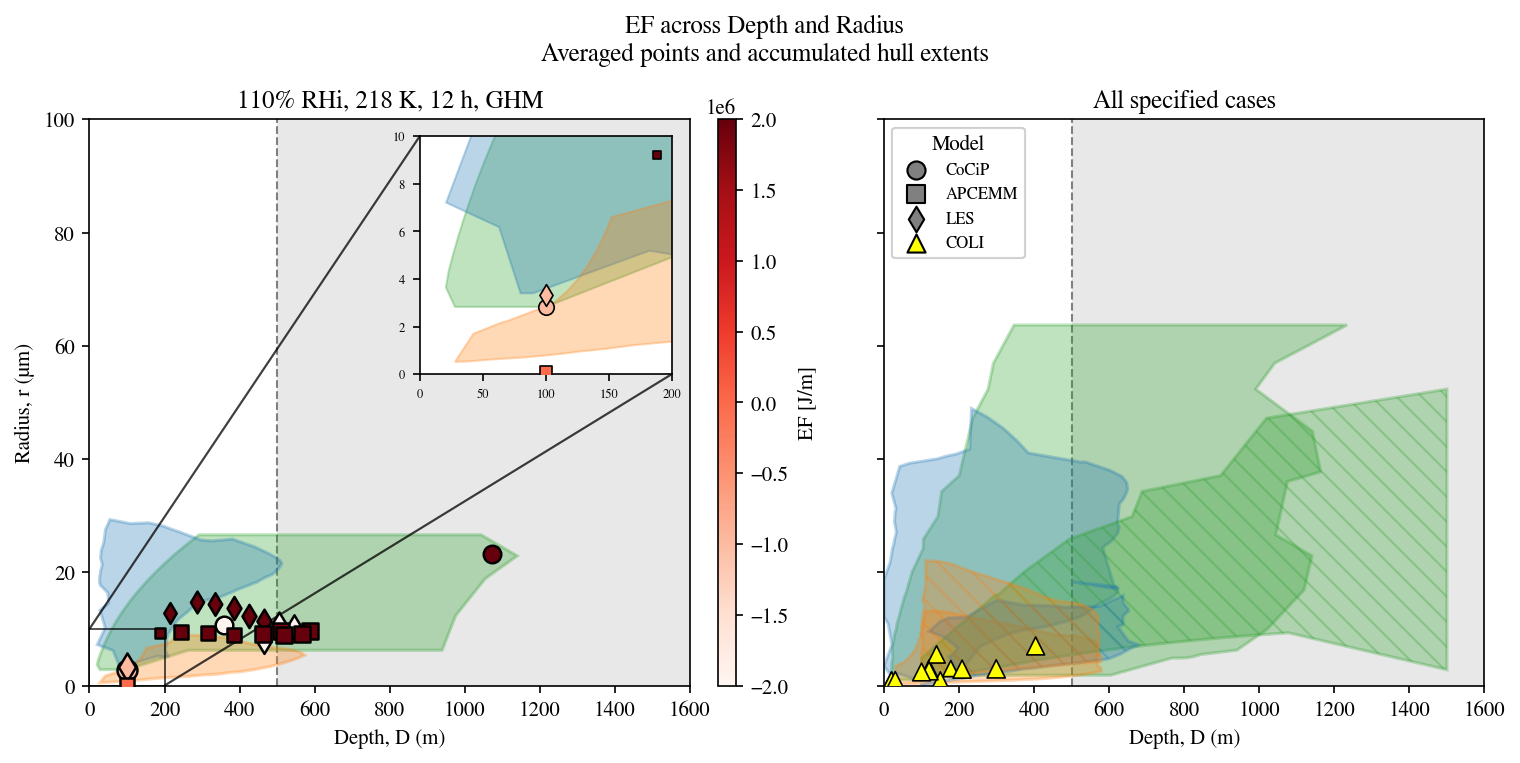

In [7]:
# --------------------------------------------------------------------------
# Entry point
# --------------------------------------------------------------------------

if __name__ == "__main__":
    coli_df = load_coli_data()

    print("\n=== Creating 2D averaged hull comparison figure ===")
    fig_case_hulls, axes_case_hulls = plot_ef_averaged_case_hulls(coli_df, MODEL_SOURCES)

    # print("\n=== Creating EF-by-model grid figure ===")
    # fig_ef_grid, axes_ef_grid = plot_ef_depth_radius_grid(MODEL_SOURCES)

    # print("\n=== Creating EF-by-model grid figure ===")
    # fig_ef_gradient, axes_ef_gradient = plot_ef_gradient_grid(MODEL_SOURCES)

    plt.show()

## 1:1 Plot

/tmp/ipykernel_4001038/3163226346.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


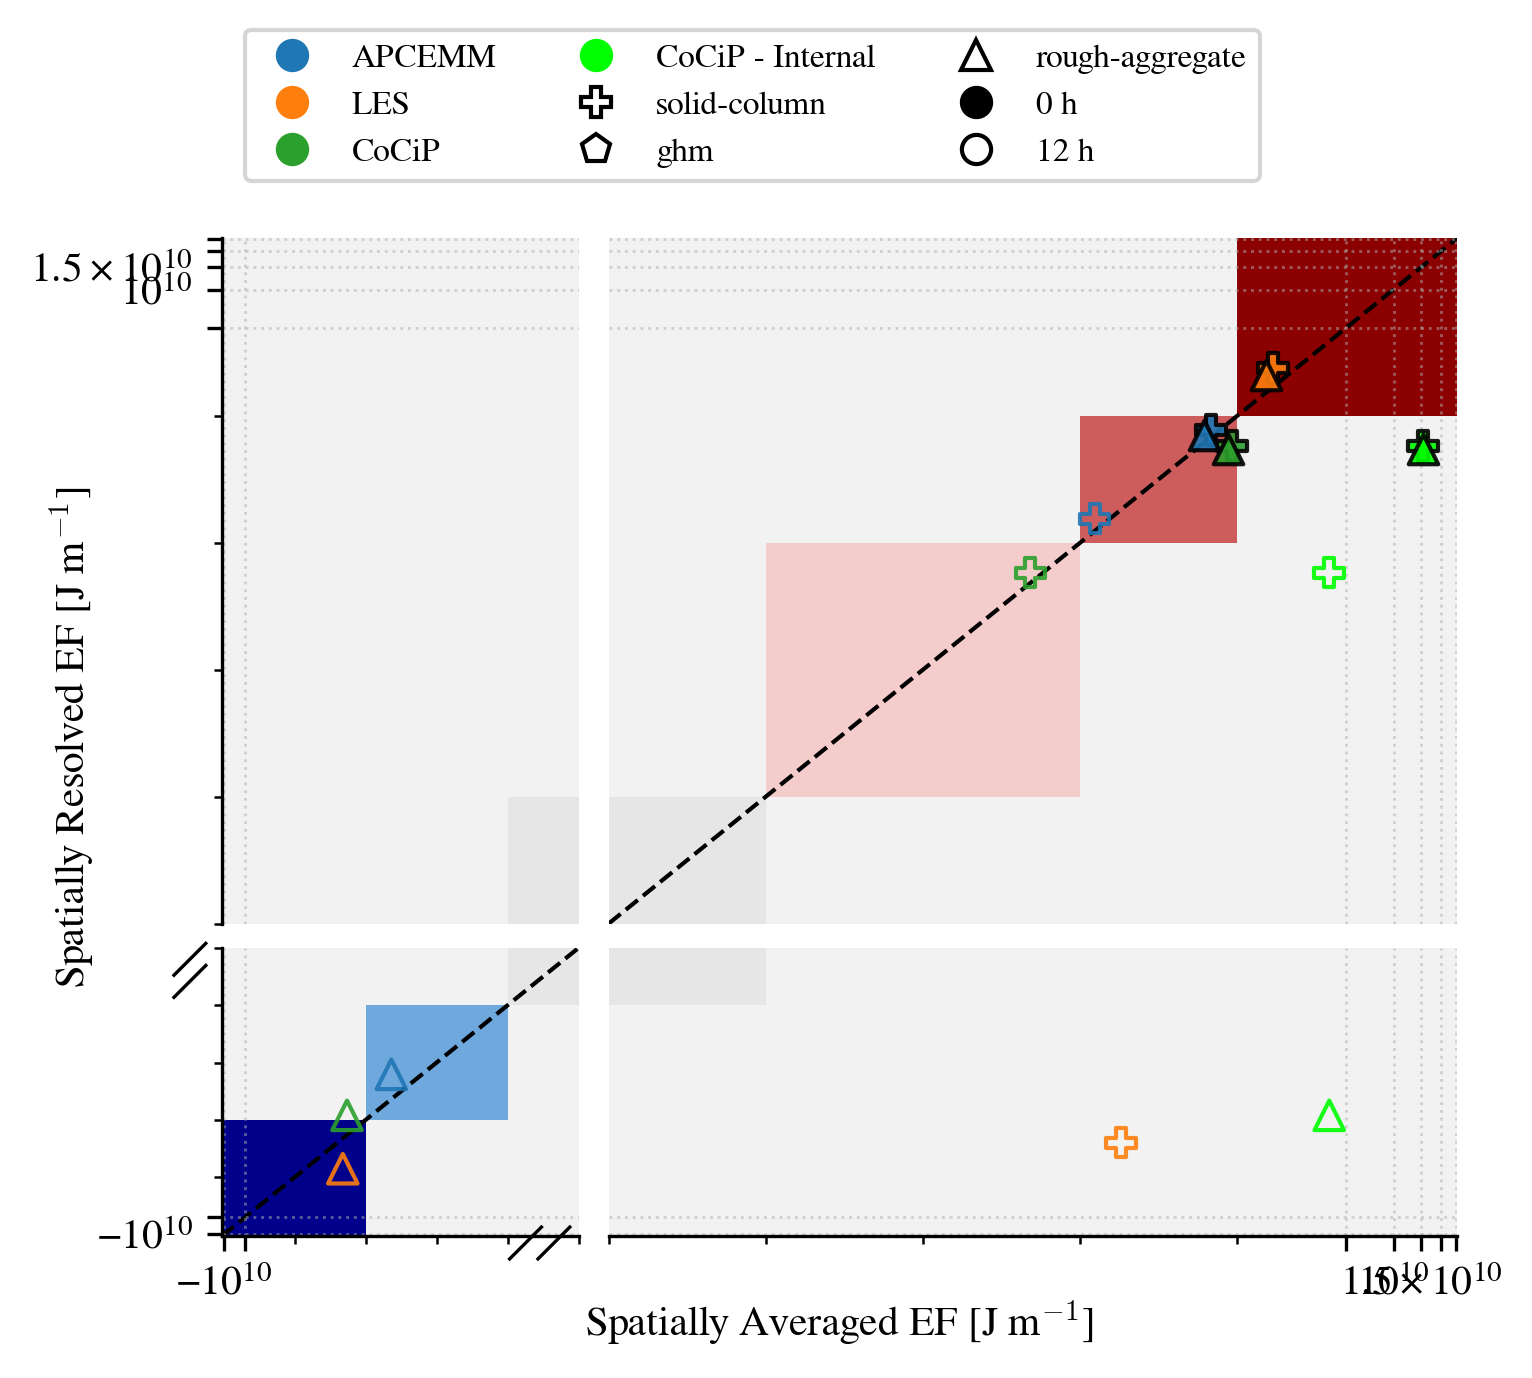

In [8]:
from matplotlib.lines import Line2D
from brokenaxes import brokenaxes

# ─────────────────────────────────────────────────────────────────────────────
# Settings
# ─────────────────────────────────────────────────────────────────────────────

MODEL_COLORS = {
    "APCEMM": "tab:blue",
    "LES": "tab:orange",
    "CoCiP": "tab:green",
    "CoCiP - Internal": "lime",
}

HABIT_MARKERS = {
    "solid-column": "P",
    "ghm": "p",
    "rough-aggregate": "^",
}

hours = [0, 12]

# Region to skip
BREAK_LOW = -1e5
BREAK_HIGH = 1e5


# ─────────────────────────────────────────────────────────────────────────────
# Gather cumulative EF data
# ─────────────────────────────────────────────────────────────────────────────

plot_data = []
test_ids = ["110T225L25"]
habits = ["solid-column", "rough-aggregate"]
for test_id in test_ids:
    for hour in hours:
        for habit in habits:
            key = (test_id, hour, habit)

            # ── APCEMM ────────────────────────────────────────────────────────
            if key in apcemm_data:
                avg_depths, avg_radii, avg_ef_cumsum, avg_iwcs = _gather_avg_points(apcemm_data, [key])
                ef_cumsum_slices = _gather_slice_points(
                    apcemm_data, [key], fields=("ef",)
                )
                avg_ef_sum = avg_ef_cumsum[-1]
                slice_ef_sum = np.nansum(ef_cumsum_slices, axis=1)[-1]

                if np.isfinite(avg_ef_sum) and np.isfinite(slice_ef_sum):
                    plot_data.append({
                        "model": "APCEMM",
                        "test_id": test_id,
                        "hour": hour,
                        "habit": habit,
                        "avg_ef": avg_ef_sum,
                        "slice_ef": slice_ef_sum,
                    })

            # ── LES ──────────────────────────────────────────────────────────
            if key in les_data:
                avg_depths, avg_radii, avg_ef_cumsum, avg_iwcs = _gather_avg_points(les_data, [key])
                ef_cumsum_slices = _gather_slice_points(
                    les_data, [key], fields=("ef",)
                )

                avg_ef_sum = avg_ef_cumsum[-1]
                slice_ef_sum = np.nansum(ef_cumsum_slices, axis=1)[-1]
                if np.isfinite(avg_ef_sum) and np.isfinite(slice_ef_sum):
                    plot_data.append({
                        "model": "LES",
                        "test_id": test_id,
                        "hour": hour,
                        "habit": habit,
                        "avg_ef": avg_ef_sum,
                        "slice_ef": slice_ef_sum,
                    })

            # ── CoCiP ─────────────────────────────────────────────────────────
            if key in C2:
                avg_depths, avg_radii, avg_ef_cumsum, avg_iwcs = _gather_avg_points(C2, [key])
                ef_cumsum_slices = _gather_slice_points(
                    C2, [key], fields=("ef",)
                )

                avg_ef_sum = avg_ef_cumsum[-1]
                slice_ef_sum = np.nansum(ef_cumsum_slices, axis=1)[-1]
                internal_pts = C2[key]["ef"]

                internal_ef_sum = np.nansum(internal_pts[2])

                if np.isfinite(avg_ef_sum) and np.isfinite(slice_ef_sum):
                    plot_data.append({
                        "model": "CoCiP",
                        "test_id": test_id,
                        "hour": hour,
                        "habit": habit,
                        "avg_ef": avg_ef_sum,
                        "slice_ef": slice_ef_sum,
                    })

                if np.isfinite(internal_ef_sum):
                    plot_data.append({
                        "model": "CoCiP - Internal",
                        "test_id": test_id,
                        "hour": hour,
                        "habit": habit,
                        "avg_ef": avg_ef_sum,
                        "slice_ef": slice_ef_sum,
                        "internal_ef": internal_ef_sum,
                    })


# ─────────────────────────────────────────────────────────────────────────────
# Determine axis limits
# ─────────────────────────────────────────────────────────────────────────────

all_ef = np.array(
    [d["avg_ef"] for d in plot_data] +
    [d["slice_ef"] for d in plot_data] +
    [d["internal_ef"] for d in plot_data if "internal_ef" in d]
)

all_ef = all_ef[np.isfinite(all_ef)]

line_min = np.nanmin(all_ef)
line_max = np.nanmax(all_ef)

# Small padding outside the actual data range
padding = 1e10

axis_min = line_min - padding
axis_max = line_max + padding


# ─────────────────────────────────────────────────────────────────────────────
# Create broken axes
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(5, 4), dpi=300)

bax = brokenaxes(
    xlims=(
        (axis_min, BREAK_LOW),
        (BREAK_HIGH, axis_max),
    ),
    ylims=(
        (axis_min, BREAK_LOW),
        (BREAK_HIGH, axis_max),
    ),
    hspace=0.05,
    wspace=0.05,
    d=0.015,
)
bax.set_yscale("symlog")
bax.set_xscale("symlog")

# ─────────────────────────────────────────────────────────────────────────────
# Fixed 2-D EF regime boxes
# ─────────────────────────────────────────────────────────────────────────────

EF_REGION_COLORS = {
    "dark_red":  "#8B0000",   # EF > 1e9
    "red":       "#CD5C5C",   # 1e8 < EF < 1e9
    "light_red": "#F4CCCC",   # 1e6 < EF < 1e8
    "gray":      "#E6E6E6",   # -1e6 < EF < 1e6
    "blue":      "#6FA8DC",   # -1e8 < EF < -1e6
    "dark_blue": "#00008B",   # EF < -1e8
}

# Color used when Avg EF and Slice EF are in different regimes
MISMATCH_COLOR = "#F2F2F2"


def ef_regime_color(regime):
    """Return the color associated with an EF regime."""
    return EF_REGION_COLORS[regime]


# ─────────────────────────────────────────────────────────────────────────────
# Define the EF regimes
# ─────────────────────────────────────────────────────────────────────────────
#
# Each tuple is:
#     (lower bound, upper bound, regime name)
#
# The ±1e5 region is omitted because it is the axis break.
#

ef_regions = [
    (-np.inf, -1e8, "dark_blue"),
    (-1e8, -1e6, "blue"),
    (-1e6, BREAK_LOW, "gray"),

    (BREAK_HIGH, 1e6, "gray"),
    (1e6, 1e8, "light_red"),
    (1e8, 1e9, "red"),
    (1e9, np.inf, "dark_red"),
]


# ─────────────────────────────────────────────────────────────────────────────
# Draw the boxes
# ─────────────────────────────────────────────────────────────────────────────

for ax in bax.axs:

    for x_low, x_high, x_regime in ef_regions:

        for y_low, y_high, y_regime in ef_regions:

            # Replace infinities with the actual visible axis limits
            x0 = axis_min if not np.isfinite(x_low) else x_low
            x1 = axis_max if not np.isfinite(x_high) else x_high

            y0 = axis_min if not np.isfinite(y_low) else y_low
            y1 = axis_max if not np.isfinite(y_high) else y_high

            # ─────────────────────────────────────────────────────────────
            # If x and y are in the same regime, use the regime color.
            #
            # If they differ, use a neutral background.
            # ─────────────────────────────────────────────────────────────

            if x_regime == y_regime:
                color = ef_regime_color(x_regime)
            else:
                color = MISMATCH_COLOR

            ax.fill_between(
                [x0, x1],
                y0,
                y1,
                color=color,
                alpha=1.0,
                linewidth=0,
                zorder=0,
            )

# ─────────────────────────────────────────────────────────────────────────────
# Plot points
# ─────────────────────────────────────────────────────────────────────────────

for d in plot_data:

    marker = HABIT_MARKERS[d["habit"]]
    color = MODEL_COLORS[d["model"]]

    # Filled for hour 0, open for hour 12
    if d["hour"] == hours[0]:
        facecolor = color
        edgecolor = "black"
    else:
        facecolor = "none"
        edgecolor = color

    if "internal_ef" in d:
        bax.scatter(
            d["internal_ef"],
            d["slice_ef"],
            marker=marker,
            s=50,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=1.0,
            alpha=0.9,
            zorder=3,
        )
    else:
        bax.scatter(
            d["avg_ef"],
            d["slice_ef"],
            marker=marker,
            s=50,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=1.0,
            alpha=0.9,
            zorder=3,
        )


# ─────────────────────────────────────────────────────────────────────────────
# 1:1 reference line
# ─────────────────────────────────────────────────────────────────────────────

# Plot the 1:1 line separately in each visible region.
bax.plot(
    [axis_min, BREAK_LOW],
    [axis_min, BREAK_LOW],
    color="k",
    linestyle="--",
    linewidth=1.0,
    zorder=1,
)

bax.plot(
    [BREAK_HIGH, axis_max],
    [BREAK_HIGH, axis_max],
    color="k",
    linestyle="--",
    linewidth=1.0,
    zorder=1,
)


# ─────────────────────────────────────────────────────────────────────────────
# Formatting
# ─────────────────────────────────────────────────────────────────────────────

bax.set_xlabel("Spatially Averaged EF [J m$^{-1}$]")
bax.set_ylabel("Spatially Resolved EF [J m$^{-1}$]")

bax.grid(
    True,
    which="major",
    linestyle=":",
    linewidth=0.7,
    alpha=0.5,
)


# ─────────────────────────────────────────────────────────────────────────────
# Legends
# ─────────────────────────────────────────────────────────────────────────────

# Model legend
model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor=color,
        markersize=7,
        label=model,
    )
    for model, color in MODEL_COLORS.items()
]

# Habit legend
habit_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        color="k",
        markerfacecolor="white",
        markersize=7,
        label=habit,
    )
    for habit, marker in HABIT_MARKERS.items()
]

# Hour legend
hour_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        color="k",
        markerfacecolor=(
            "black" if i == 0 else "white"
        ),
        markersize=7,
        label=f"{hour} h",
    )
    for i, hour in enumerate(hours)
]

legend = fig.legend(
    handles=model_handles + habit_handles + hour_handles,
    loc="upper center",
    frameon=True,
    ncol=3,
    bbox_to_anchor=(0.5, 1.15),
    fontsize=8,
)


# ─────────────────────────────────────────────────────────────────────────────
# Finish
# ─────────────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.show()